# CM52060  Bayesian Data Science: Assessment Part B
## Hierarchical Bayesian Modelling of Mechanical Component Degradation

**Notebook  Part B Analysis**

This notebook works through all the Part B coding tasks in order:
1. Data loading and exploration
2. Baseline hierarchical model Equation (1)
3. Enhanced hierarchical model Equation (2)
4. Blind test predictions
5. Saving model data for the deployable notebook

In [1]:
!pip install numpyro jax jaxlib arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 8.6 MB/s eta 0:00:00


## 1. Setup

Install dependencies (only needed once) and import all required libraries.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
jax.config.update('jax_platforms', 'cpu')
numpyro.set_host_device_count(4)

print(f"numpyro {numpyro.__version__}  |  jax {jax.__version__}")
import arviz as az

# arviz 1.0 requires raising the subplot limit for per-component traces
az.rcParams['plot.max_subplots'] = 200

numpyro 0.20.1  |  jax 0.7.2


## 2. Load and Explore the Data

The CSV contains 879 integrity measurements from 75 components (indices 0–74).
Components 0–49 are well-observed (training set).
Components 50–74 have sparse early measurements (blind test set).

In [3]:
data = pd.read_csv('bml-component-data.csv')
print(f"Dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Dataset shape: (879, 9)
Columns: ['ID', 'index', 'X1', 'X2', 'X3', 'X4', 'X5', 'day', 'integrity']


,ID,index,X1,X2,X3,X4,X5,day,integrity
0,K#0000,0,1.897,1.111,0.585,1.436,3.684,1.0,94.203
1,K#0000,0,1.897,1.111,0.585,1.436,3.684,3.0,90.663
2,K#0000,0,1.897,1.111,0.585,1.436,3.684,5.0,76.650
3,K#0000,0,1.897,1.111,0.585,1.436,3.684,7.0,74.893
4,K#0000,0,1.897,1.111,0.585,1.436,3.684,8.0,73.923


In [4]:
train_df = data[data['index'] < 50]
test_df  = data[data['index'] >= 50]

print(f"Training components (0–49): {train_df['index'].nunique()} components, "
      f"{len(train_df)} observations")
print(f"Test components  (50–74): {test_df['index'].nunique()} components, "
      f"{len(test_df)} observations")
print()
print("Observations per test component:")
print(test_df.groupby('index').size().to_string())

Training components (0–49): 50 components, 805 observations
Test components  (50–74): 25 components, 74 observations

Observations per test component:
index
50    4
51    4
52    4
53    5
54    3
55    1
56    5
57    4
58    2
59    2
60    1
61    3
62    1
63    4
64    6
65    1
66    1
67    1
68    3
69    1
70    2
71    1
72    8
73    3
74    4


In [5]:
comp_idx = data['index'].values.astype(int)
days     = data['day'].values
y_obs    = data['integrity'].values
N_comp   = 75


X_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
X_feats = data.groupby('index')[X_cols].first().values.astype(float)
X_jax   = jnp.array(X_feats)

print(f"comp_idx shape: {comp_idx.shape}")
print(f"X_feats shape:  {X_feats.shape}")
print(f"\nX feature statistics (across 75 components):")
pd.DataFrame(X_feats, columns=X_cols).describe().round(3)

comp_idx shape: (879,)
X_feats shape:  (75, 5)

X feature statistics (across 75 components):


,X1,X2,X3,X4,X5
count,75.000,75.000,75.000,75.000,75.000
mean,1.555,1.918,1.478,2.020,1.648
std,1.582,2.454,1.420,3.005,2.035
min,0.140,0.044,0.078,0.162,0.123
25%,0.617,0.676,0.440,0.486,0.414
50%,1.062,1.177,0.900,1.109,0.984
75%,1.917,1.975,2.012,1.972,2.069
max,9.175,15.516,6.821,14.272,12.921


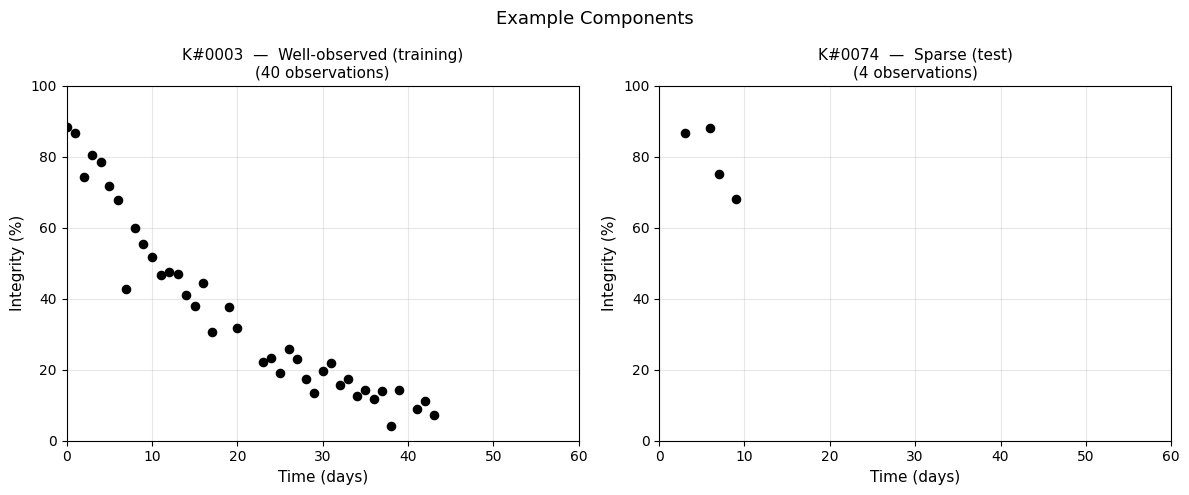

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ci, label in zip(axes,
                         [3,   74],
                         ['Well-observed (training)', 'Sparse (test)']):
    cdf = data[data['index'] == ci]
    ax.scatter(cdf['day'], cdf['integrity'], color='black', s=35, zorder=5)
    ax.set_xlim(0, 60); ax.set_ylim(0, 100)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Integrity (%)', fontsize=11)
    ax.set_title(f"{cdf['ID'].iloc[0]}  —  {label}\n({len(cdf)} observations)",
                 fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('Example Components', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Baseline Hierarchical Bayesian Model

### 3.1 Model Specification

The client's suggested functional form (Equation 1) is:

$$f_i(t) = u_i \exp\!\left(-\frac{v_i\, t}{100}\right)$$

with additive Gaussian noise: $y_i(t) = f_i(t) + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma_y^2)$.

**Hierarchical structure** instead of fitting each component independently, we place a
shared population distribution over the per component parameters:

$$u_i \sim \mathcal{N}(\mu_u,\, \sigma_u^2) \qquad v_i \sim \mathcal{N}(\mu_v,\, \sigma_v^2)$$

**Non-centred reparameterisation** is used for efficient HMC sampling
(avoids funnel geometry for data-sparse components):

$$u_i = \mu_u + \tilde{u}_i\,\sigma_u, \quad \tilde{u}_i \sim \mathcal{N}(0,1)$$
$$v_i = \mu_v + \tilde{v}_i\,\sigma_v, \quad \tilde{v}_i \sim \mathcal{N}(0,1)$$

**Priors:**

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| $\mu_u$ | $\mathcal{N}(90, 10^2)$ | Client advises $u_i \in [80, 100]$ |
| $\sigma_u$ | HalfNormal(10) | Non-negative, weakly informative |
| $\mu_v$ | $\mathcal{N}(5, 3^2)$ | Client advises $v_i \in [1, 10]$ |
| $\sigma_v$ | HalfNormal(3) | Non-negative, weakly informative |
| $\sigma_y$ | HalfNormal(10) | Non-negative observation noise |

In [7]:
def baseline_model(comp_idx, days, y_obs=None):
    """
    Hierarchical Bayesian baseline degradation model.
    f_i(t) = u_i * exp(-v_i * t / 100)
    """

    mu_u    = numpyro.sample('mu_u',    dist.Normal(90., 10.))
    sigma_u = numpyro.sample('sigma_u', dist.HalfNormal(10.))
    mu_v    = numpyro.sample('mu_v',    dist.Normal(5., 3.))
    sigma_v = numpyro.sample('sigma_v', dist.HalfNormal(3.))
    sigma_y = numpyro.sample('sigma_y', dist.HalfNormal(10.))


    with numpyro.plate('components', N_comp):
        u_raw = numpyro.sample('u_raw', dist.Normal(0., 1.))
        v_raw = numpyro.sample('v_raw', dist.Normal(0., 1.))

    u_i = numpyro.deterministic('u_i', mu_u + u_raw * sigma_u)
    v_i = numpyro.deterministic('v_i', mu_v + v_raw * sigma_v)


    f = u_i[comp_idx] * jnp.exp(-v_i[comp_idx] * days / 100.)
    numpyro.sample('y', dist.Normal(f, sigma_y), obs=y_obs)

### 3.2 Run the HMC / NUTS Sampler

We run 4 parallel chains with 2,000 warm-up and 2,000 sampling iterations each
(8,000 posterior samples total), as recommended in the spec.

In [8]:
nuts_kernel = NUTS(baseline_model)
mcmc_base   = MCMC(nuts_kernel,
                   num_warmup=2000,
                   num_samples=2000,
                   num_chains=4)

mcmc_base.run(jax.random.PRNGKey(42), comp_idx, days, y_obs)

print("Baseline model — posterior summary (hyper-parameters only):")
mcmc_base.print_summary(exclude_deterministic=True)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

Baseline model — posterior summary (hyper-parameters only):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mu_u     89.70      0.88     89.71     88.27     91.15   5737.32      1.00
      mu_v      3.92      0.21      3.91      3.58      4.28   1353.44      1.00
   sigma_u      5.28      0.81      5.23      3.96      6.60   4105.36      1.00
   sigma_v      1.58      0.17      1.57      1.31      1.86   2716.44      1.00
   sigma_y      5.11      0.13      5.10      4.88      5.32  11230.39      1.00
  u_raw[0]      0.82      0.47      0.81      0.05      1.58  12980.93      1.00
  u_raw[1]     -0.45      0.83     -0.46     -1.81      0.93  14693.39      1.00
  u_raw[2]      1.70      0.46      1.69      0.92      2.41  10142.65      1.00
  u_raw[3]     -0.08      0.43     -0.08     -0.81      0.61  13692.50      1.00
  u_raw[4]     -0.49      0.75     -0.49     -1.68      0.74  14738.18      1.00
  u_raw[5]     -0.06      0.77     -0.06     -1.

In [9]:
samps_base    = mcmc_base.get_samples()
samps_base_gc = mcmc_base.get_samples(group_by_chain=True)
n_div = int(mcmc_base.get_extra_fields().get('diverging', jnp.zeros(1)).sum())
print(f"Number of divergences: {n_div}")
idata_base = az.from_numpyro(mcmc_base)


Number of divergences: 0


### 3.3 Trace Plots

A well-converged sampler should show:
- **KDE (left):** unimodal, approximately Gaussian posteriors
- **Trace (right):** 'fuzzy caterpillar' all 4 chains overlapping, no drift or structure

In [10]:
def az_trace(idata, var_names, title):
    """Wrapper around arviz.plot_trace as required by spec Section 4.2.1."""
    az.plot_trace(idata, var_names=var_names)
    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

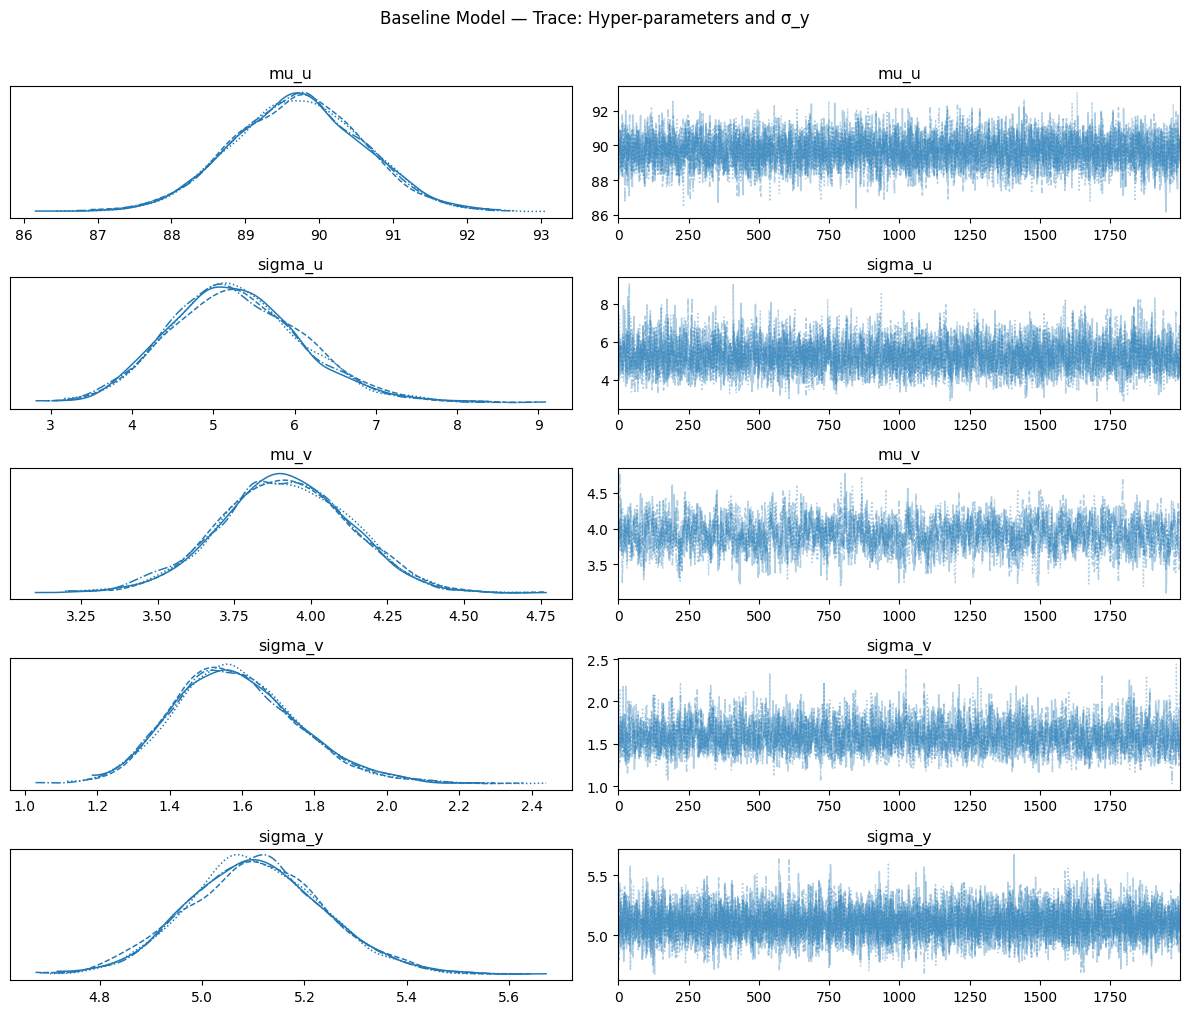

In [11]:
az_trace(idata_base,
         var_names=['mu_u', 'sigma_u', 'mu_v', 'sigma_v', 'sigma_y'],
         title='Baseline Model — Trace: Hyper-parameters and σ_y')

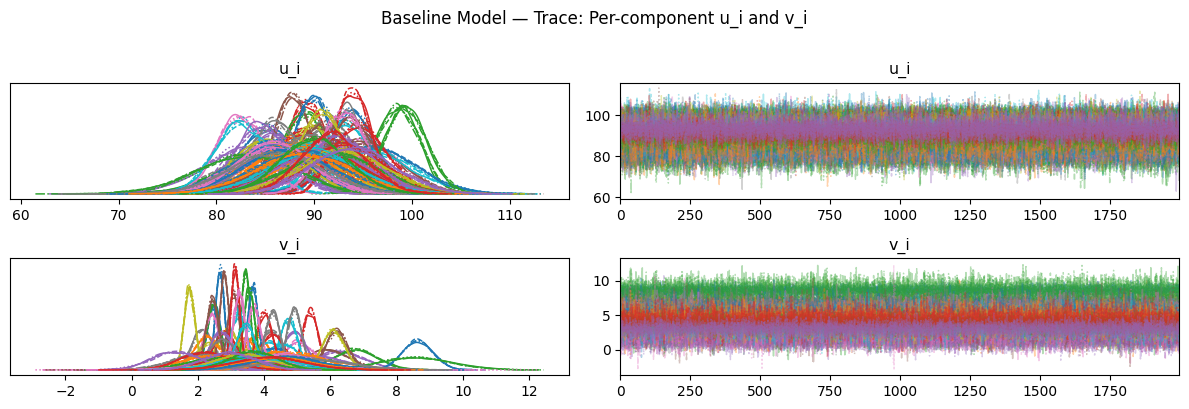

In [12]:
# Trace plots for per-component u_i and v_i (compact=True equivalent in arviz 1.0)
az_trace(idata_base,
         var_names=['u_i', 'v_i'],
         title='Baseline Model — Trace: Per-component u_i and v_i')

### 3.4 Posterior Predictive Fits

For each component we:
1. Draw samples of $u_i$, $v_i$ from the posterior
2. Compute $f_i(t)$ for each sample → **posterior function samples**
3. Mean and std of those samples → **posterior mean** and **function uncertainty**
4. Add posterior noise variance → **full predictive uncertainty** (incl. $\sigma_y$)

As per the spec (Section 4.2.1), error bars are $\pm 1.96 \times$ the respective std.

In [13]:
def posterior_predict(ci, samps, t_arr, X=None):
    t_arr = np.atleast_1d(np.asarray(t_arr))

    u  = np.array(samps['u_i'])[:, ci]
    v  = np.array(samps['v_i'])[:, ci]
    sy = np.array(samps['sigma_y'])

    if X is not None:
        w     = np.array(samps['w'])
        eff_v = v + w @ X[ci]
    else:
        eff_v = v


    f          = u[:, None] * np.exp(-eff_v[:, None] * t_arr[None, :] / 100.)
    f_mean     = f.mean(axis=0)
    f_std      = f.std(axis=0)
    noise_var  = (sy ** 2).mean()
    total_std  = np.sqrt(f.var(axis=0) + noise_var)

    return f_mean, f_std, total_std

In [14]:
def plot_component_fit(ci, samps, model_name='Baseline', X=None,
                       t_max=60, ax=None):
    """
    Plot data, posterior mean, and both uncertainty bands for one component.
    """
    cdf    = data[data['index'] == ci]
    comp_id = cdf['ID'].iloc[0]
    n_obs  = len(cdf)

    t_plot              = np.linspace(0, t_max, 400)
    f_mean, f_std, t_std = posterior_predict(ci, samps, t_plot, X=X)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(cdf['day'], cdf['integrity'],
               color='black', s=40, zorder=5, label=f'Data  ({n_obs} obs)')
    ax.plot(t_plot, f_mean, color='firebrick', lw=2, label='Posterior mean')
    ax.fill_between(t_plot,
                    f_mean - 1.96 * f_std,
                    f_mean + 1.96 * f_std,
                    alpha=0.35, color='steelblue',
                    label='95% fn. uncertainty')
    ax.fill_between(t_plot,
                    f_mean - 1.96 * t_std,
                    f_mean + 1.96 * t_std,
                    alpha=0.15, color='orange',
                    label='95% predictive (incl. noise)')

    ax.set_xlim(0, t_max); ax.set_ylim(0, 100)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Integrity (%)', fontsize=11)
    ax.set_title(f'{model_name} — {comp_id}  ({n_obs} obs)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    if standalone:
        plt.tight_layout()
        plt.show()

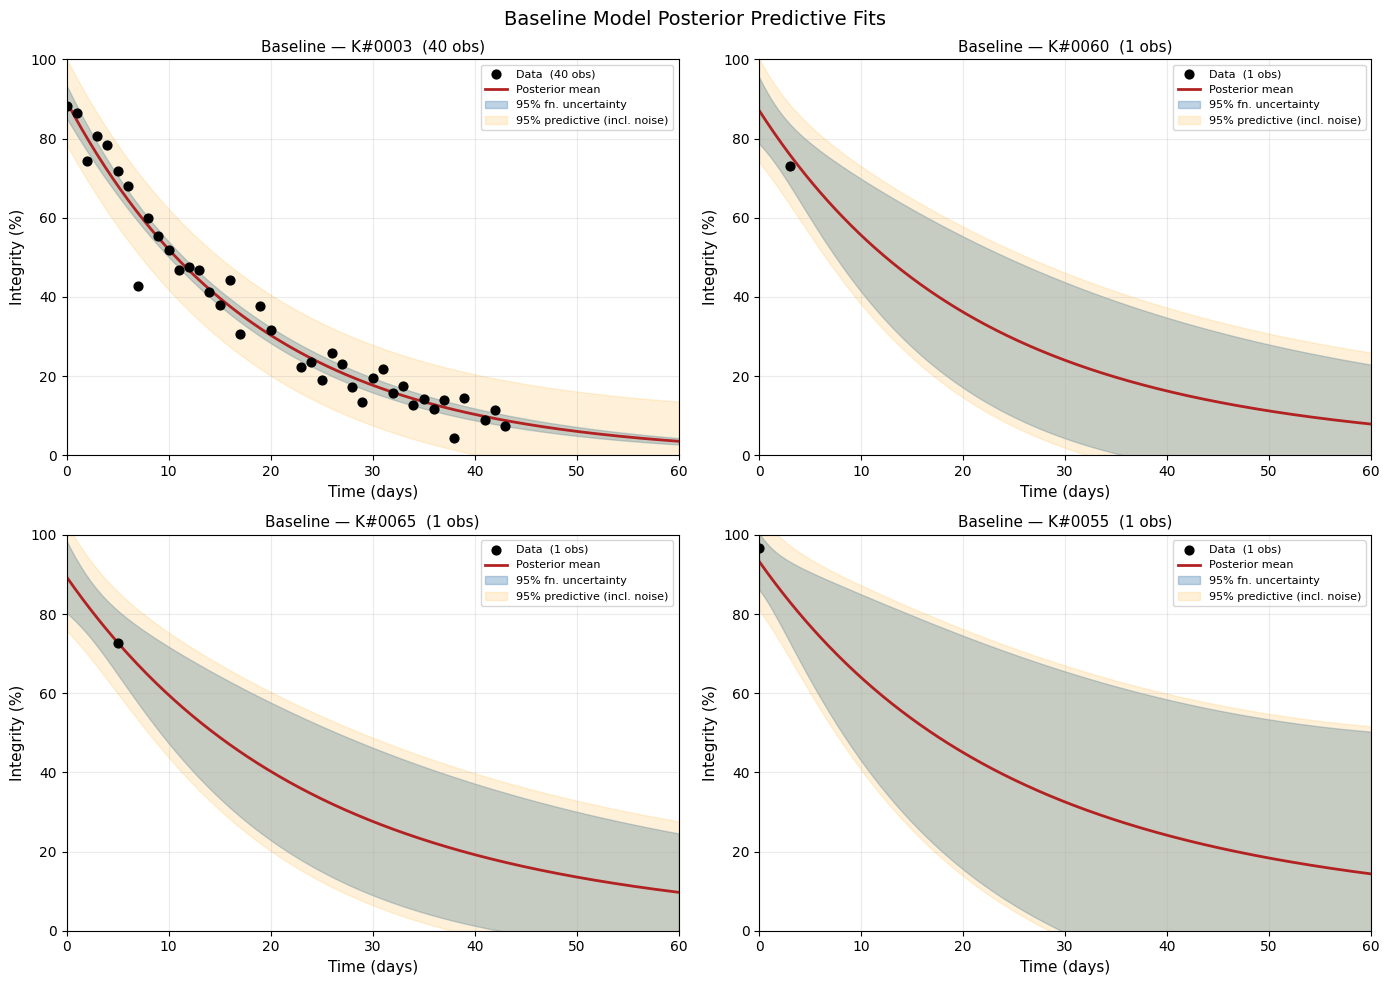

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ci in zip(axes.flat, [3, 60, 65, 55]):
    plot_component_fit(ci, samps_base, model_name='Baseline', X=None, ax=ax)

plt.suptitle('Baseline Model Posterior Predictive Fits', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Enhanced Hierarchical Bayesian Model

### 4.1 Model Specification

The enhanced model (Equation 2) incorporates the five physical component
characteristics X1–X5 into the effective decay rate:

$$f_i(t) = u_i \exp\!\left(-\frac{\left(v_i + \sum_{j=1}^{5} w_j x_{ji}\right) t}{100}\right)$$

The weights $w_j$ are **shared across all components** and learn from the full
dataset. They are given a hierarchical shrinkage prior:

$$w_j \sim \mathcal{N}(0,\, \sigma_w^2), \qquad \sigma_w \sim \text{HalfNormal}(2)$$

This regularises weights towards zero unless the data strongly supports a
non-zero value, which is important given that some features may be irrelevant.

The prior on $\mu_v$ is shifted to $\mathcal{N}(2, 2^2)$ because once
the X features absorb part of the variation, the baseline decay rate $v_i$
is expected to be smaller.

In [16]:
def enhanced_model(comp_idx, days, X, y_obs=None):
    """
    Enhanced hierarchical Bayesian degradation model.
    f_i(t) = u_i * exp( -(v_i + sum_j w_j x_ji) * t / 100 )
    """

    mu_u    = numpyro.sample('mu_u',    dist.Normal(90., 10.))
    sigma_u = numpyro.sample('sigma_u', dist.HalfNormal(10.))
    mu_v    = numpyro.sample('mu_v',    dist.Normal(2., 2.))
    sigma_v = numpyro.sample('sigma_v', dist.HalfNormal(2.))
    sigma_y = numpyro.sample('sigma_y', dist.HalfNormal(10.))


    sigma_w = numpyro.sample('sigma_w', dist.HalfNormal(2.))
    w       = numpyro.sample('w', dist.Normal(jnp.zeros(5),
                                               sigma_w * jnp.ones(5)))
    with numpyro.plate('components', N_comp):
        u_raw = numpyro.sample('u_raw', dist.Normal(0., 1.))
        v_raw = numpyro.sample('v_raw', dist.Normal(0., 1.))

    u_i = numpyro.deterministic('u_i', mu_u + u_raw * sigma_u)
    v_i = numpyro.deterministic('v_i', mu_v + v_raw * sigma_v)
    eff_v = v_i[comp_idx] + X[comp_idx] @ w
    f = u_i[comp_idx] * jnp.exp(-eff_v * days / 100.)
    numpyro.sample('y', dist.Normal(f, sigma_y), obs=y_obs)

### 4.2 Run the HMC / NUTS Sampler

In [17]:
nuts_kernel  = NUTS(enhanced_model)
mcmc_enhanced = MCMC(nuts_kernel,
                     num_warmup=2000,
                     num_samples=2000,
                     num_chains=4)

mcmc_enhanced.run(jax.random.PRNGKey(99), comp_idx, days, X_jax, y_obs)

print("Enhanced model — posterior summary (hyper-parameters only):")
mcmc_enhanced.print_summary(exclude_deterministic=True)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

Enhanced model — posterior summary (hyper-parameters only):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mu_u     90.36      0.76     90.36     89.06     91.56   3158.96      1.00
      mu_v      1.99      0.15      1.99      1.74      2.24   2775.94      1.00
   sigma_u      4.79      0.63      4.77      3.75      5.80   3117.09      1.00
   sigma_v      0.34      0.06      0.34      0.23      0.44   2606.78      1.00
   sigma_w      0.67      0.30      0.59      0.29      1.05   5359.81      1.00
   sigma_y      5.09      0.13      5.09      4.88      5.30   7723.67      1.00
  u_raw[0]      0.81      0.47      0.81      0.01      1.56   7167.20      1.00
  u_raw[1]      0.26      0.77      0.27     -1.01      1.50   7118.55      1.00
  u_raw[2]      1.70      0.47      1.69      0.89      2.43   5780.24      1.00
  u_raw[3]     -0.21      0.45     -0.20     -0.95      0.53   7786.31      1.00
  u_raw[4]     -0.15      0.69     -0.16     -1.

In [18]:
samps_enh    = mcmc_enhanced.get_samples()
samps_enh_gc = mcmc_enhanced.get_samples(group_by_chain=True)

n_div = int(mcmc_enhanced.get_extra_fields().get('diverging', jnp.zeros(1)).sum())
print(f"Number of divergences: {n_div}")
idata_enh = az.from_numpyro(mcmc_enhanced)


Number of divergences: 0


### 4.3 Trace Plots — Enhanced Model (hyper-parameters and u_i, v_i)

As specified, weight parameters $w_j$ are shown separately in Section 4.4.

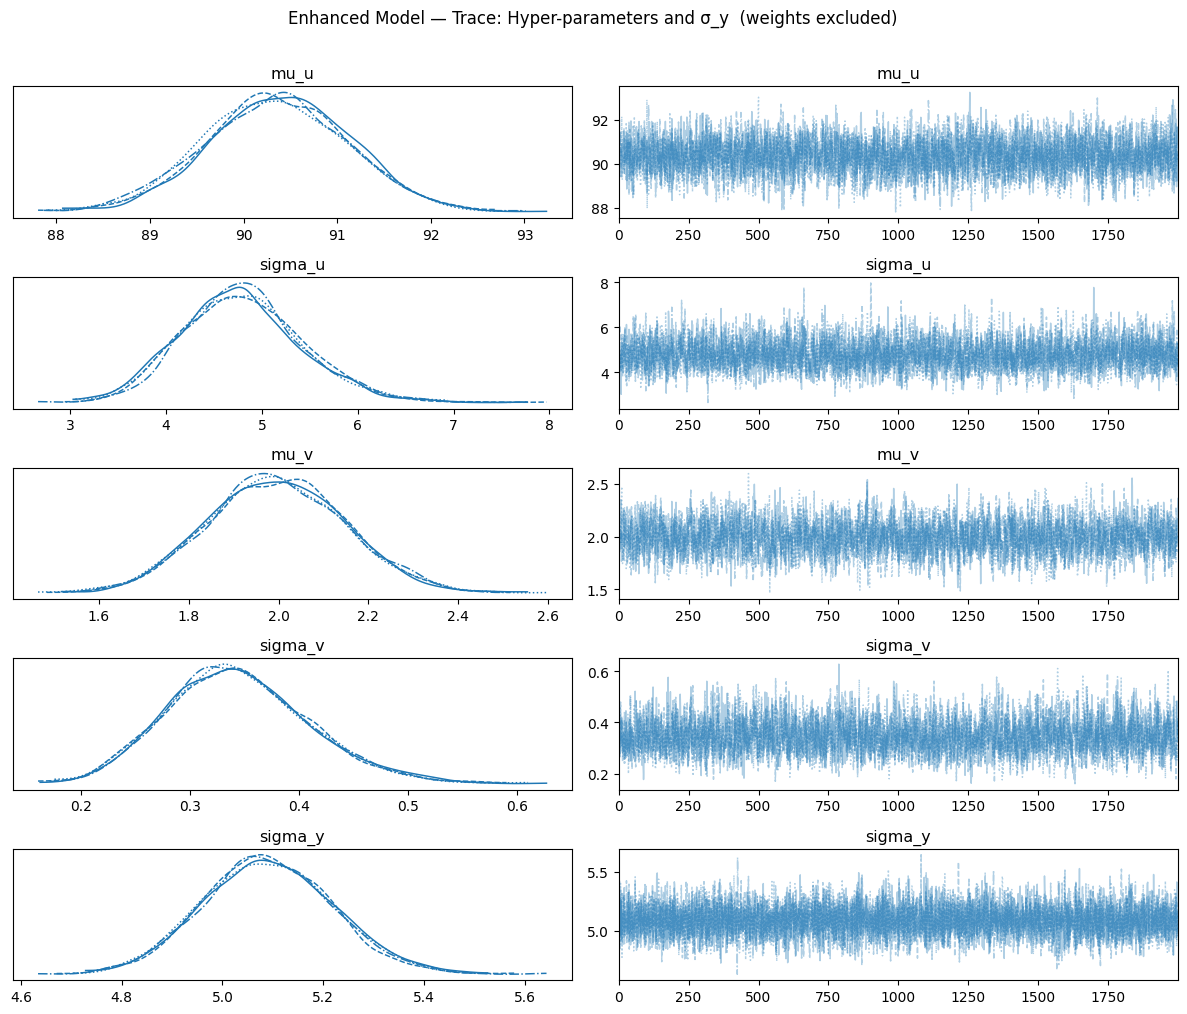

In [19]:
az_trace(idata_enh,
         var_names=['mu_u', 'sigma_u', 'mu_v', 'sigma_v', 'sigma_y'],
         title='Enhanced Model — Trace: Hyper-parameters and σ_y  (weights excluded)')

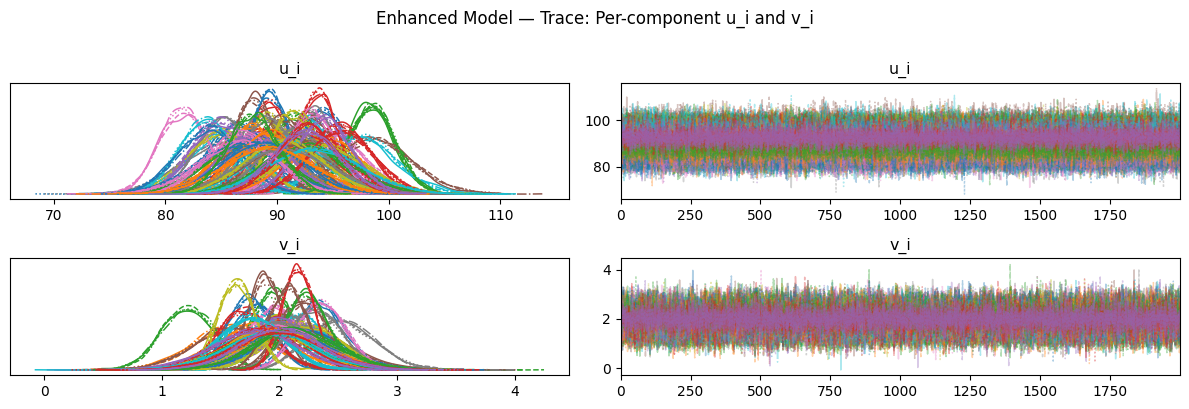

In [20]:
az_trace(idata_enh,
         var_names=['u_i', 'v_i'],
         title='Enhanced Model — Trace: Per-component u_i and v_i')

### 4.4 Trace Plots Feature Weights

These plots directly address which physical characteristics
most influence degradation rate.

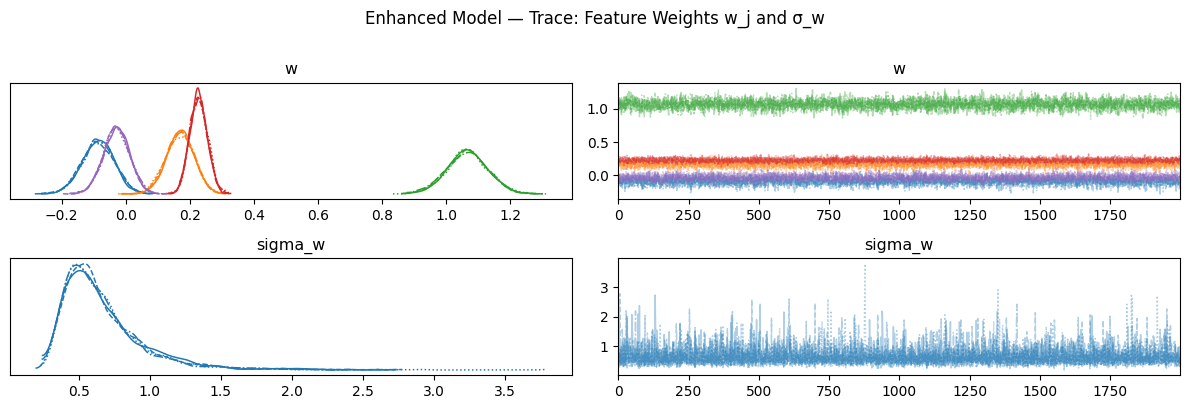

In [21]:
az_trace(idata_enh,
         var_names=['w', 'sigma_w'],
         title='Enhanced Model — Trace: Feature Weights w_j and σ_w')

In [22]:
w_samps = np.array(samps_enh['w'])

print(f"{'Feature':<10} {'Mean':>8} {'Std':>8} {'2.5%':>8} {'97.5%':>8}  {'Credibly ≠ 0?'}")
print('-' * 58)
for j, feat in enumerate(['X1','X2','X3','X4','X5']):
    vals  = w_samps[:, j]
    lo    = np.percentile(vals, 2.5)
    hi    = np.percentile(vals, 97.5)
    nonzero = 'YES' if lo > 0 or hi < 0 else 'no'
    print(f"{feat:<10} {vals.mean():>8.4f} {vals.std():>8.4f} "
          f"{lo:>8.4f} {hi:>8.4f}  {nonzero}")

Feature        Mean      Std     2.5%    97.5%  Credibly ≠ 0?
----------------------------------------------------------
X1          -0.0865   0.0507  -0.1879   0.0112  no
X2           0.1694   0.0437   0.0824   0.2530  YES
X3           1.0664   0.0642   0.9376   1.1926  YES
X4           0.2274   0.0274   0.1752   0.2814  YES
X5          -0.0290   0.0408  -0.1095   0.0504  no


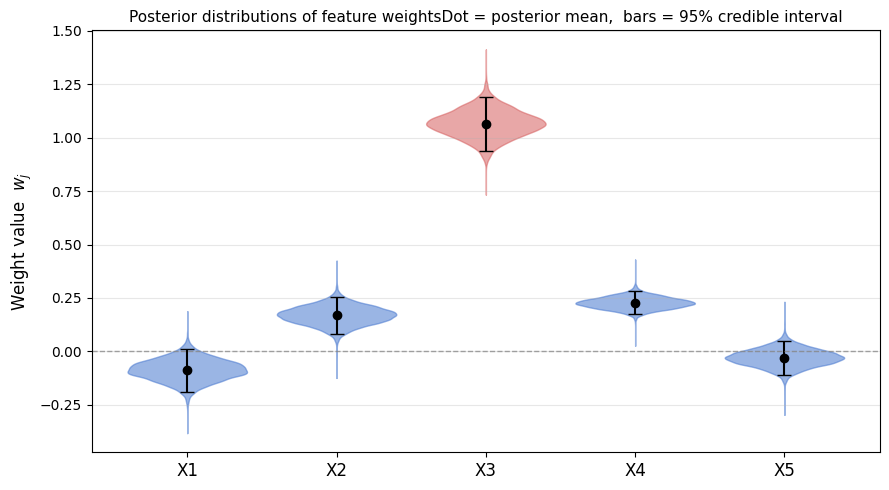

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(1, 6)
colors_w  = ['#4878CF','#4878CF','#D65F5F','#4878CF','#4878CF']

for j in range(5):
    vals = w_samps[:, j]
    kde  = gaussian_kde(vals)
    xs   = np.linspace(vals.min() - 0.1, vals.max() + 0.1, 400)
    ys   = kde(xs)
    norm_ys = ys / ys.max() * 0.4
    ax.fill_betweenx(xs,
                     positions[j] - norm_ys,
                     positions[j] + norm_ys,
                     alpha=0.55, color=colors_w[j])
    ax.plot(positions[j], vals.mean(), 'o', color='black', zorder=5, ms=6)
    ax.errorbar(positions[j], vals.mean(),
                yerr=[[vals.mean() - np.percentile(vals, 2.5)],
                      [np.percentile(vals, 97.5) - vals.mean()]],
                fmt='none', color='black', capsize=5, lw=1.5)

ax.axhline(0, color='grey', lw=1, ls='--', alpha=0.7)
ax.set_xticks(positions)
ax.set_xticklabels([f'X{j+1}' for j in range(5)], fontsize=12)
ax.set_ylabel('Weight value  $w_j$', fontsize=12)
ax.set_title('Posterior distributions of feature weights'
             'Dot = posterior mean,  bars = 95% credible interval', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Posterior Predictive Fits Enhanced Model

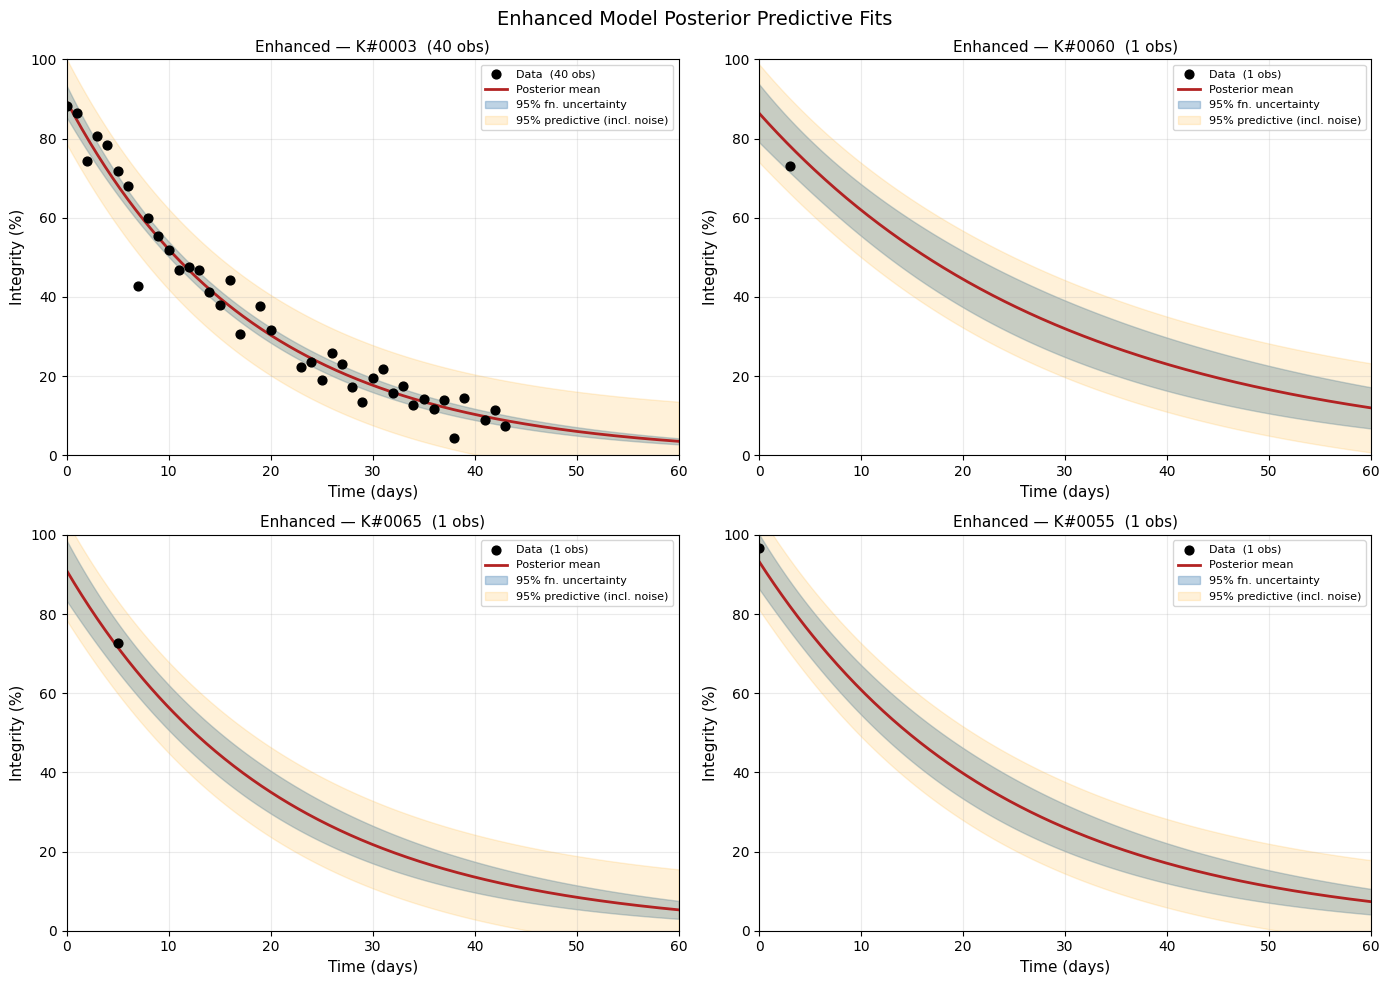

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ci in zip(axes.flat, [3, 60, 65, 55]):
    plot_component_fit(ci, samps_enh, model_name='Enhanced', X=X_feats, ax=ax)

plt.suptitle('Enhanced Model Posterior Predictive Fits', fontsize=14)
plt.tight_layout()
plt.show()

### 4.6 Side-by-side Comparison: Baseline vs Enhanced

A direct comparison on one sparse test component to show the effect of
incorporating X features.

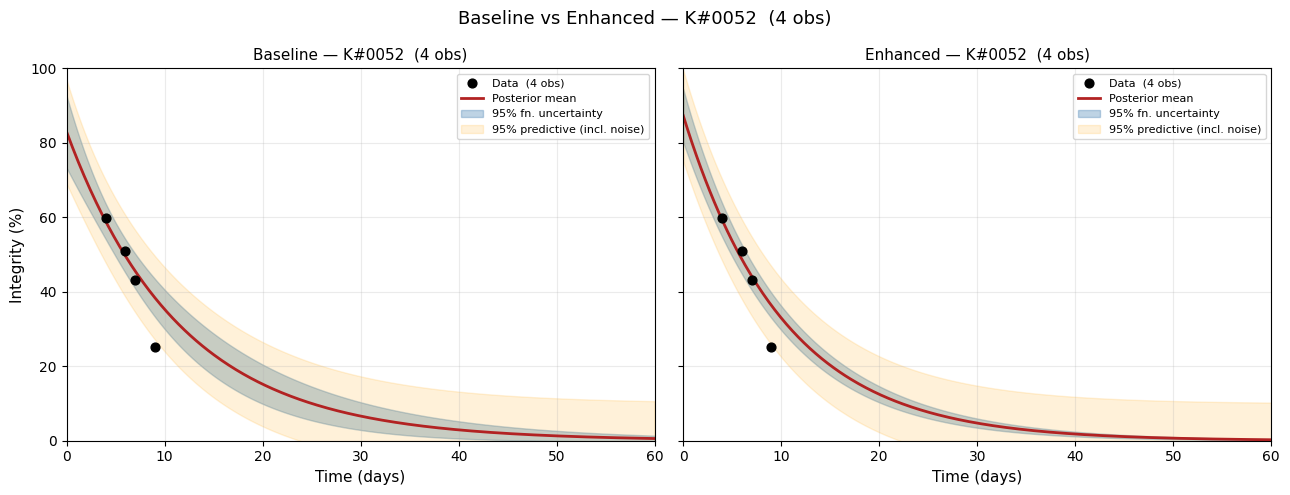

In [25]:
ci = 52
cdf = data[data['index'] == ci]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, samps, name, Xf in [
        (axes[0], samps_base, 'Baseline',  None),
        (axes[1], samps_enh,  'Enhanced',  X_feats)]:
    plot_component_fit(ci, samps, model_name=name, X=Xf, ax=ax)

axes[1].set_ylabel('')
plt.suptitle(f"Baseline vs Enhanced — {cdf['ID'].iloc[0]}  ({len(cdf)} obs)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Blind Test Predictions

For each of the 25 test components (indices 50–74), compute:

$$P\!\left(\text{integrity} \leq 30\%\ \text{at}\ t = 30\right)$$

We use the **enhanced model** as specified (Section 4.3 of the brief).

Two equivalent approaches are available (spec Section 5.2.2); we use both
as a cross-check:

1. **Monte Carlo count**  fraction of posterior function samples $f_i(30) \leq 30$
2. **Normal CDF** use posterior mean and std of $f_i(30)$ in `norm.cdf`

In [26]:
T_PRED    = 30.0
THRESHOLD = 30.0

results = []

for ci in range(50, 75):
    comp_id = data[data['index'] == ci]['ID'].iloc[0]


    u   = np.array(samps_enh['u_i'])[:, ci]
    v   = np.array(samps_enh['v_i'])[:, ci]
    w   = np.array(samps_enh['w'])
    ev  = v + w @ X_feats[ci]
    f30 = u * np.exp(-ev * T_PRED / 100.)


    prob_mc = float(np.mean(f30 <= THRESHOLD))


    prob_cdf = float(norm.cdf(THRESHOLD, loc=f30.mean(), scale=f30.std()))

    results.append({
        'ID':          comp_id,
        'index':       ci,
        'probability': prob_mc,
        'prob_cdf':    prob_cdf,
        'f30_mean':    f30.mean(),
        'f30_std':     f30.std(),
    })


results_df = pd.DataFrame(results)
print(results_df[['ID','index','f30_mean','f30_std','probability','prob_cdf']].to_string(index=False))

    ID  index  f30_mean  f30_std  probability  prob_cdf
K#0050     50 33.973165 3.301430     0.107500  0.114398
K#0051     51 16.818044 1.608434     1.000000  1.000000
K#0052     52  4.728800 0.628994     1.000000  1.000000
K#0053     53 30.641503 2.694210     0.422000  0.405900
K#0054     54 41.193809 3.857551     0.001875  0.001855
K#0055     55 25.993149 3.014291     0.904125  0.908123
K#0056     56 21.190263 2.109151     0.999750  0.999985
K#0057     57 50.959302 4.976248     0.000000  0.000013
K#0058     58 13.015901 1.863807     1.000000  1.000000
K#0059     59 29.221773 3.962989     0.613875  0.577841
K#0060     60 31.933987 3.648074     0.298875  0.298008
K#0061     61 41.270132 3.956139     0.000625  0.002194
K#0062     62 37.168132 4.012108     0.026875  0.036999
K#0063     63 41.007582 3.969536     0.000500  0.002777
K#0064     64 55.880100 5.508553     0.000000  0.000001
K#0065     65 21.770470 2.425108     0.998375  0.999655
K#0066     66 11.850052 2.093564     1.000000  1

## 6. Save Model Data for Deployable Notebook

The `deployable.ipynb` notebook loads pre computed posterior samples from disk
rather than re-running MCMC. We save the relevant arrays here.

In [27]:
import os
os.makedirs('model_data', exist_ok=True)
np.save('model_data/samps_enh_ui.npy', np.array(samps_enh['u_i']))
np.save('model_data/samps_enh_vi.npy', np.array(samps_enh['v_i']))
np.save('model_data/samps_enh_w.npy',  np.array(samps_enh['w']))
np.save('model_data/samps_enh_sy.npy', np.array(samps_enh['sigma_y']))
np.save('model_data/X_feats.npy', X_feats)
prob_series = results_df.set_index('index')['probability']
comp_meta = data.groupby('index')[['ID','X1','X2','X3','X4','X5']].first().reset_index()
comp_meta['probability'] = comp_meta['index'].map(prob_series)
comp_meta = comp_meta[comp_meta['index'] >= 50]
comp_meta.to_csv('model_data/comp_meta.csv', index=False)
results_df[['ID', 'index', 'probability']].to_csv('model_data/predictions.csv', index=False)
print("Saved to model_data/:")
for f in sorted(os.listdir('model_data')):
    size = os.path.getsize(f'model_data/{f}')
    print(f"  {f:<28} {size/1024:.1f} KB")

Saved to model_data/:
  X_feats.npy                  3.1 KB
  comp_meta.csv                1.2 KB
  predictions.csv              0.4 KB
  samps_enh_sy.npy             31.4 KB
  samps_enh_ui.npy             2343.9 KB
  samps_enh_vi.npy             2343.9 KB
  samps_enh_w.npy              156.4 KB
